# Naive Bayes Classification - Diabetes Prediction

## Problem Statement

Diabetes is one of the most prevalent chronic diseases worldwide, affecting millions of people and placing a significant burden on healthcare systems. Early detection and diagnosis of diabetes is critical for effective treatment and prevention of complications such as heart disease, kidney failure, and vision loss.

The objective of this project is to build a classification model that can predict whether a patient is diabetic or non-diabetic based on certain diagnostic measurements. The dataset used is the Pima Indians Diabetes Database, originally from the National Institute of Diabetes and Digestive and Kidney Diseases. All patients in this dataset are females of Pima Indian heritage, aged 21 years or older.

The diagnostic features available in the dataset are:
- Pregnancies: Number of times pregnant
- Glucose: Plasma glucose concentration (2 hours after a glucose tolerance test)
- BloodPressure: Diastolic blood pressure (mm Hg)
- SkinThickness: Triceps skin fold thickness (mm)
- Insulin: 2-Hour serum insulin (mu U/ml)
- BMI: Body mass index (weight in kg / height in m squared)
- DiabetesPedigreeFunction: A function that scores the likelihood of diabetes based on family history
- Age: Age in years
- Outcome: Target variable (1 = Diabetic, 0 = Non-Diabetic)

In this notebook, we will perform the following steps:
1. Exploratory Data Analysis (EDA) to understand data distributions and relationships
2. Data Preprocessing including handling zero/missing values, outlier treatment, and feature scaling
3. Multicollinearity check using Variance Inflation Factor (VIF)
4. Model building using Gaussian Naive Bayes
5. Model building using Logistic Regression for comparison
6. Model evaluation using Accuracy, Precision, Recall, F1-Score, AUC, and ROC Curves
7. Final model comparison and selection


## 1. Import Libraries

In [4]:
# Import necessary libraries for data manipulation, visualization, and modeling

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, confusion_matrix, classification_report,
                             roc_curve, roc_auc_score, precision_score, recall_score, f1_score)
from statsmodels.stats.outliers_influence import variance_inflation_factor

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')

print("All libraries imported successfully.")


All libraries imported successfully.


## 2. Load and Inspect the Dataset

In [6]:
# Load the dataset
data = pd.read_csv("diabetes.csv")

# Display the first few rows
print("First 5 rows of the dataset:")
data.head()


First 5 rows of the dataset:


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [7]:
# Check the shape of the dataset
print("Dataset shape: {} rows and {} columns".format(data.shape[0], data.shape[1]))


Dataset shape: 768 rows and 9 columns


In [8]:
# Check data types and non-null counts
print("Dataset Info:")
print("-" * 50)
data.info()


Dataset Info:
--------------------------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [9]:
# Check for null values
print("Null values in each column:")
print(data.isnull().sum())


Null values in each column:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


## 3. Exploratory Data Analysis (EDA)

Let us explore the dataset to understand the distribution of features, relationships between variables, and the class balance of the target variable.


In [11]:
# Statistical summary of the dataset
print("Statistical Summary:")
data.describe()


Statistical Summary:


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


From the statistical summary, we can observe that certain columns such as Glucose, BloodPressure, SkinThickness, Insulin, and BMI have minimum values of 0. This is medically impossible and these zeros likely represent missing or unrecorded values. We will handle these in the data preprocessing step.


In [13]:
# Check how many zero values exist in columns where zero is not valid
zero_columns = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
print("Count of zero values in columns where zero is invalid:")
print("-" * 50)
for col in zero_columns:
    zero_count = (data[col] == 0).sum()
    zero_pct = round(zero_count / len(data) * 100, 2)
    print("{}: {} zeros ({}%)".format(col, zero_count, zero_pct))


Count of zero values in columns where zero is invalid:
--------------------------------------------------
Glucose: 5 zeros (0.65%)
BloodPressure: 35 zeros (4.56%)
SkinThickness: 227 zeros (29.56%)
Insulin: 374 zeros (48.7%)
BMI: 11 zeros (1.43%)


Target variable distribution:
Outcome
0    500
1    268
Name: count, dtype: int64

Percentage distribution:
Outcome
0    65.1
1    34.9
Name: proportion, dtype: float64


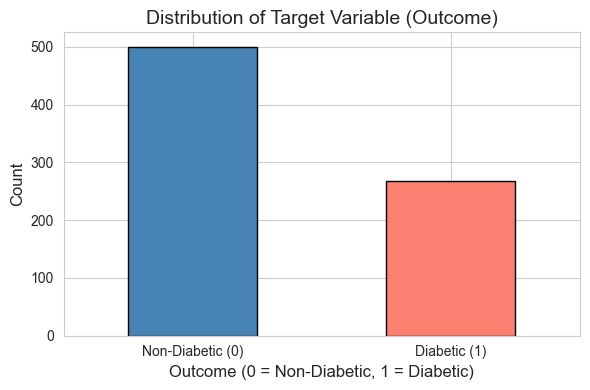

In [14]:
# Target variable distribution
print("Target variable distribution:")
print(data['Outcome'].value_counts())
print()
print("Percentage distribution:")
print(round(data['Outcome'].value_counts(normalize=True) * 100, 2))

fig, ax = plt.subplots(figsize=(6, 4))
data['Outcome'].value_counts().plot(kind='bar', color=['steelblue', 'salmon'], edgecolor='black', ax=ax)
ax.set_title('Distribution of Target Variable (Outcome)', fontsize=14)
ax.set_xlabel('Outcome (0 = Non-Diabetic, 1 = Diabetic)', fontsize=12)
ax.set_ylabel('Count', fontsize=12)
ax.set_xticklabels(['Non-Diabetic (0)', 'Diabetic (1)'], rotation=0)
plt.tight_layout()
plt.show()


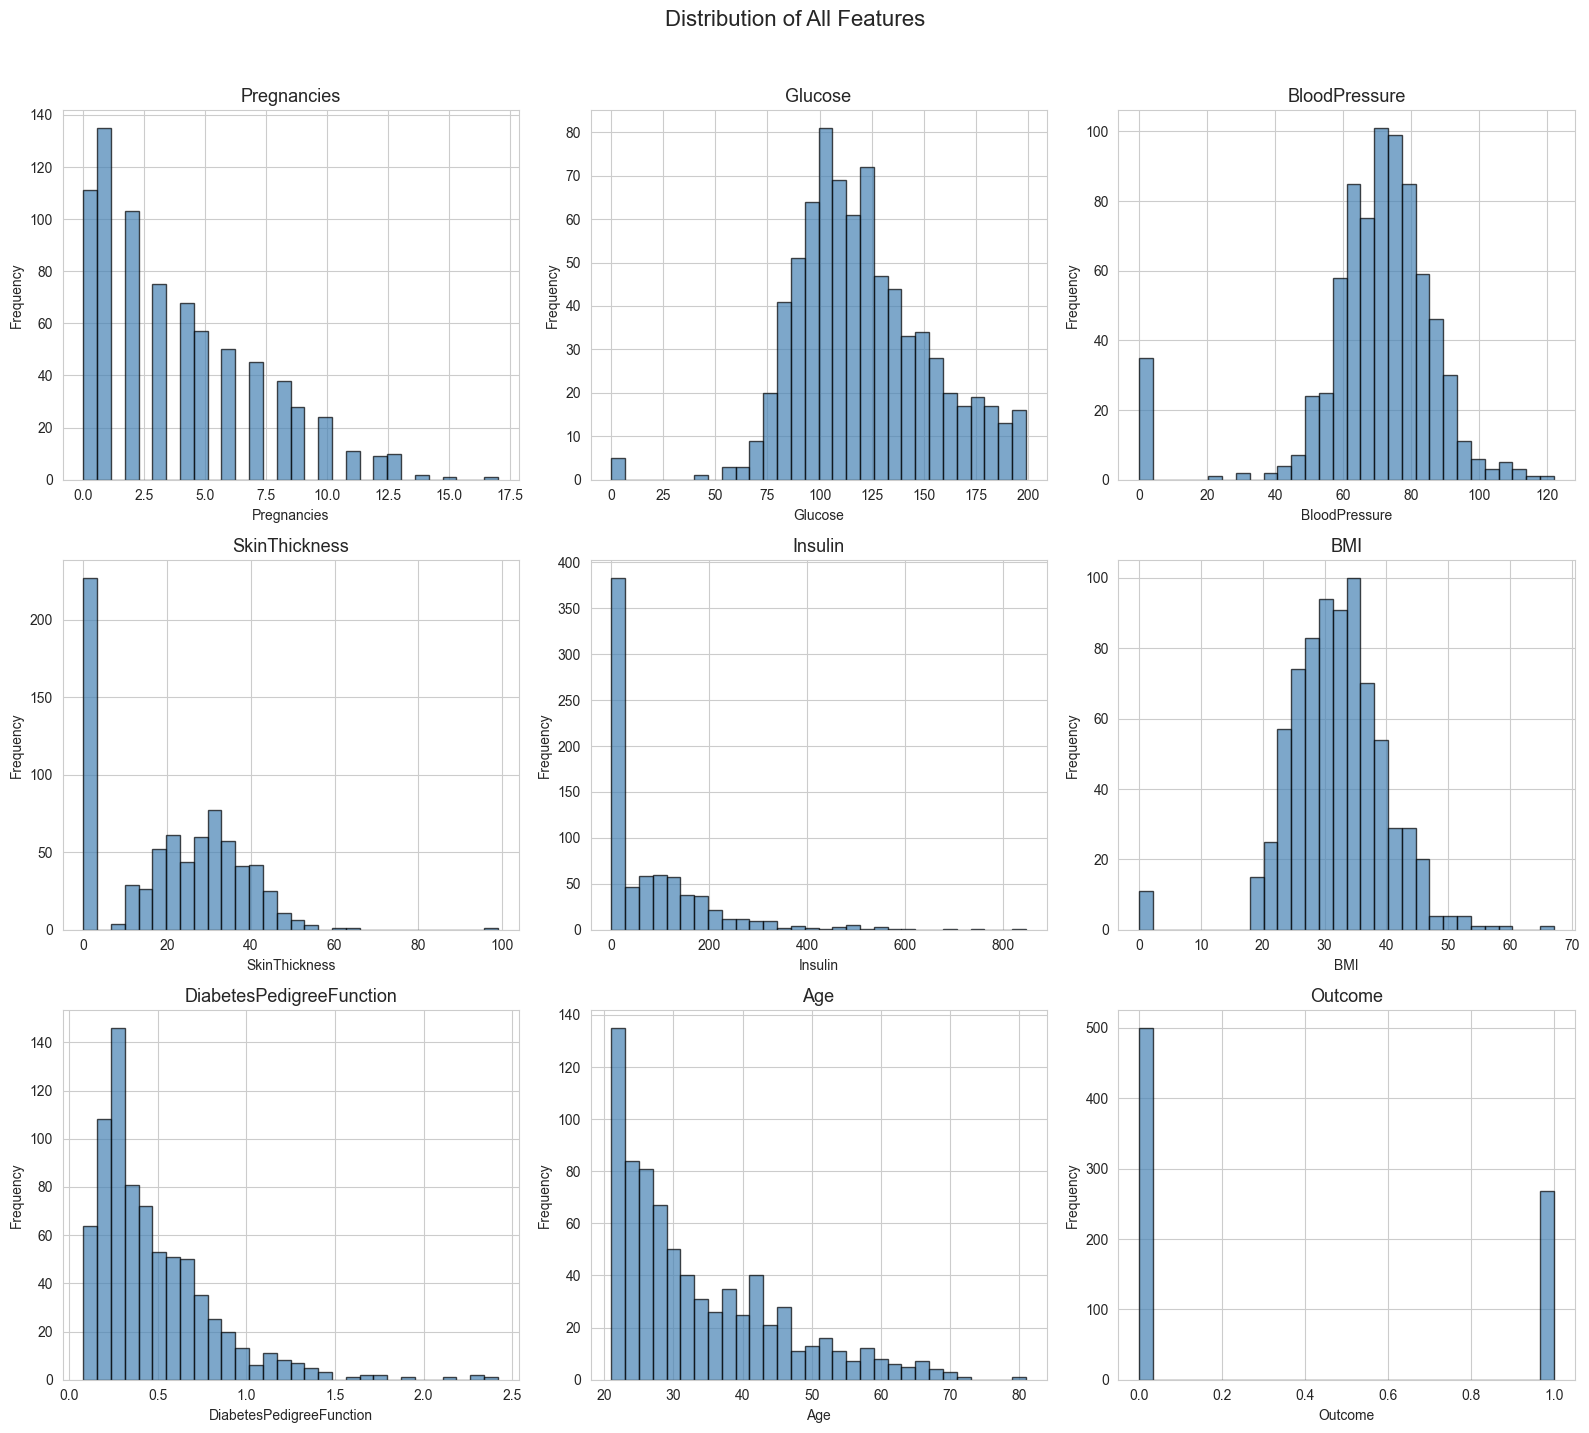

In [15]:
# Distribution of all features using histograms
fig, axes = plt.subplots(3, 3, figsize=(16, 14))
fig.suptitle('Distribution of All Features', fontsize=16, y=1.02)

for idx, column in enumerate(data.columns):
    row = idx // 3
    col = idx % 3
    axes[row, col].hist(data[column], bins=30, color='steelblue', edgecolor='black', alpha=0.7)
    axes[row, col].set_title(column, fontsize=13)
    axes[row, col].set_xlabel(column, fontsize=10)
    axes[row, col].set_ylabel('Frequency', fontsize=10)

plt.tight_layout()
plt.show()


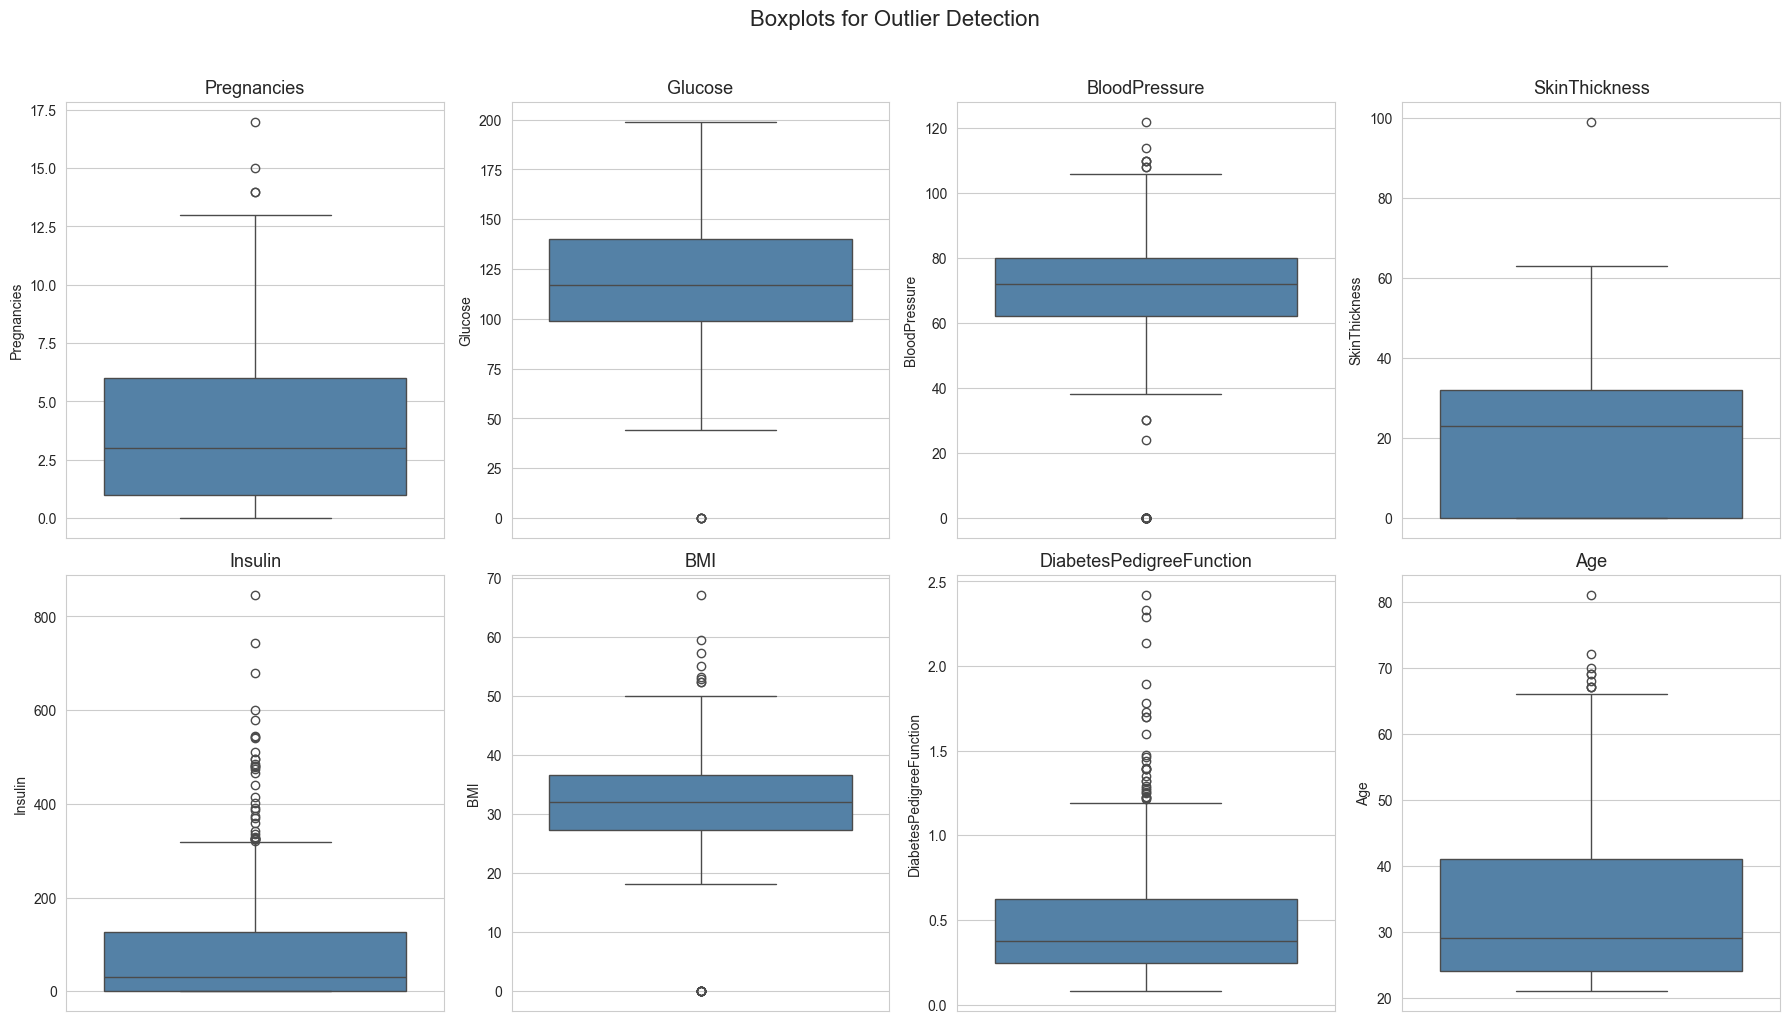

In [16]:
# Boxplots to identify outliers
fig, axes = plt.subplots(2, 4, figsize=(18, 10))
fig.suptitle('Boxplots for Outlier Detection', fontsize=16, y=1.02)

feature_cols = [col for col in data.columns if col != 'Outcome']
for idx, column in enumerate(feature_cols):
    row = idx // 4
    col = idx % 4
    sns.boxplot(y=data[column], ax=axes[row, col], color='steelblue')
    axes[row, col].set_title(column, fontsize=13)

plt.tight_layout()
plt.show()


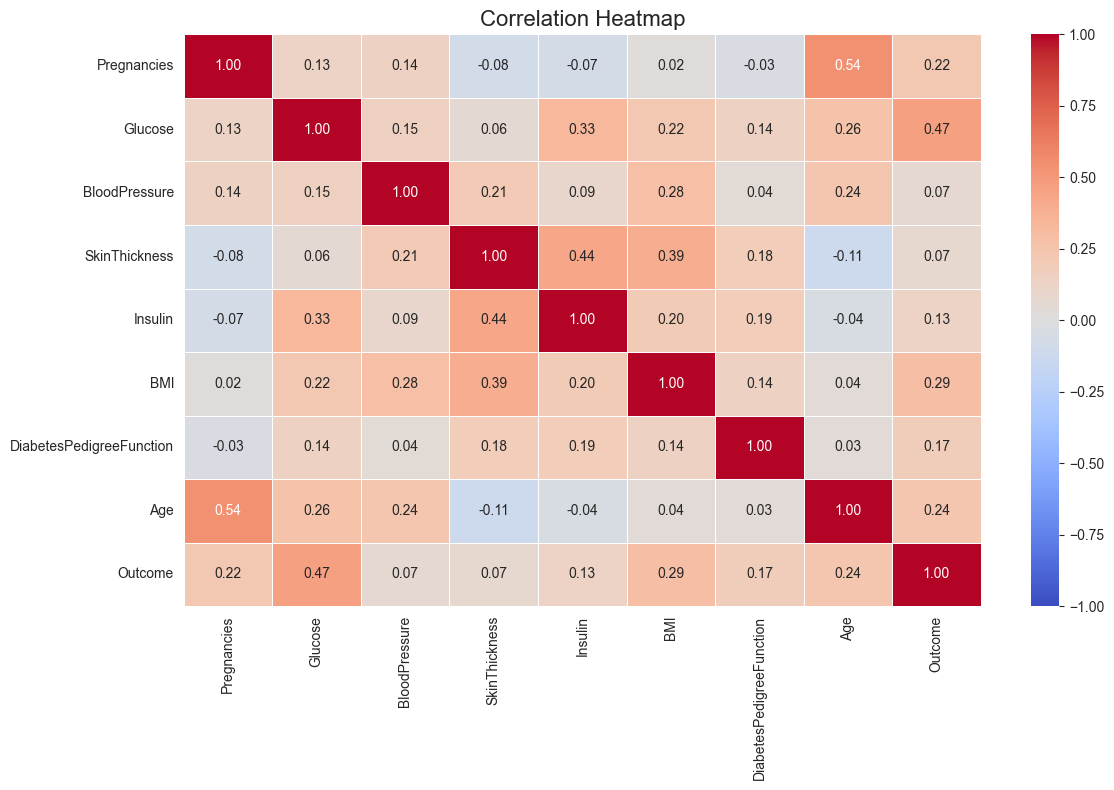

In [17]:
# Correlation heatmap
plt.figure(figsize=(12, 8))
correlation_matrix = data.corr()
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, vmin=-1, vmax=1)
plt.title('Correlation Heatmap', fontsize=16)
plt.tight_layout()
plt.show()


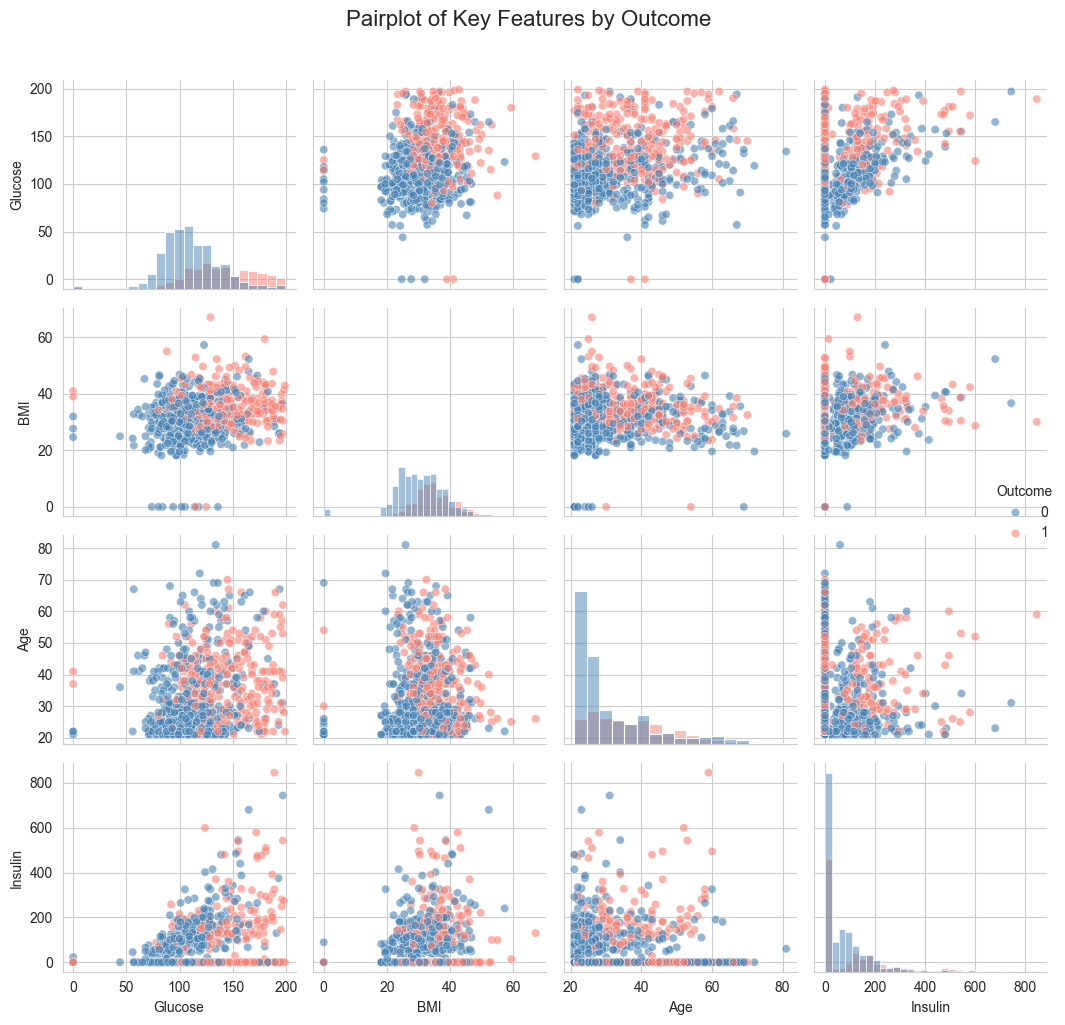

In [18]:
# Pairwise relationship between key features and the target variable
key_features = ['Glucose', 'BMI', 'Age', 'Insulin', 'Outcome']
sns.pairplot(data[key_features], hue='Outcome', palette=['steelblue', 'salmon'],
             diag_kind='hist', plot_kws={'alpha': 0.6})
plt.suptitle('Pairplot of Key Features by Outcome', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()


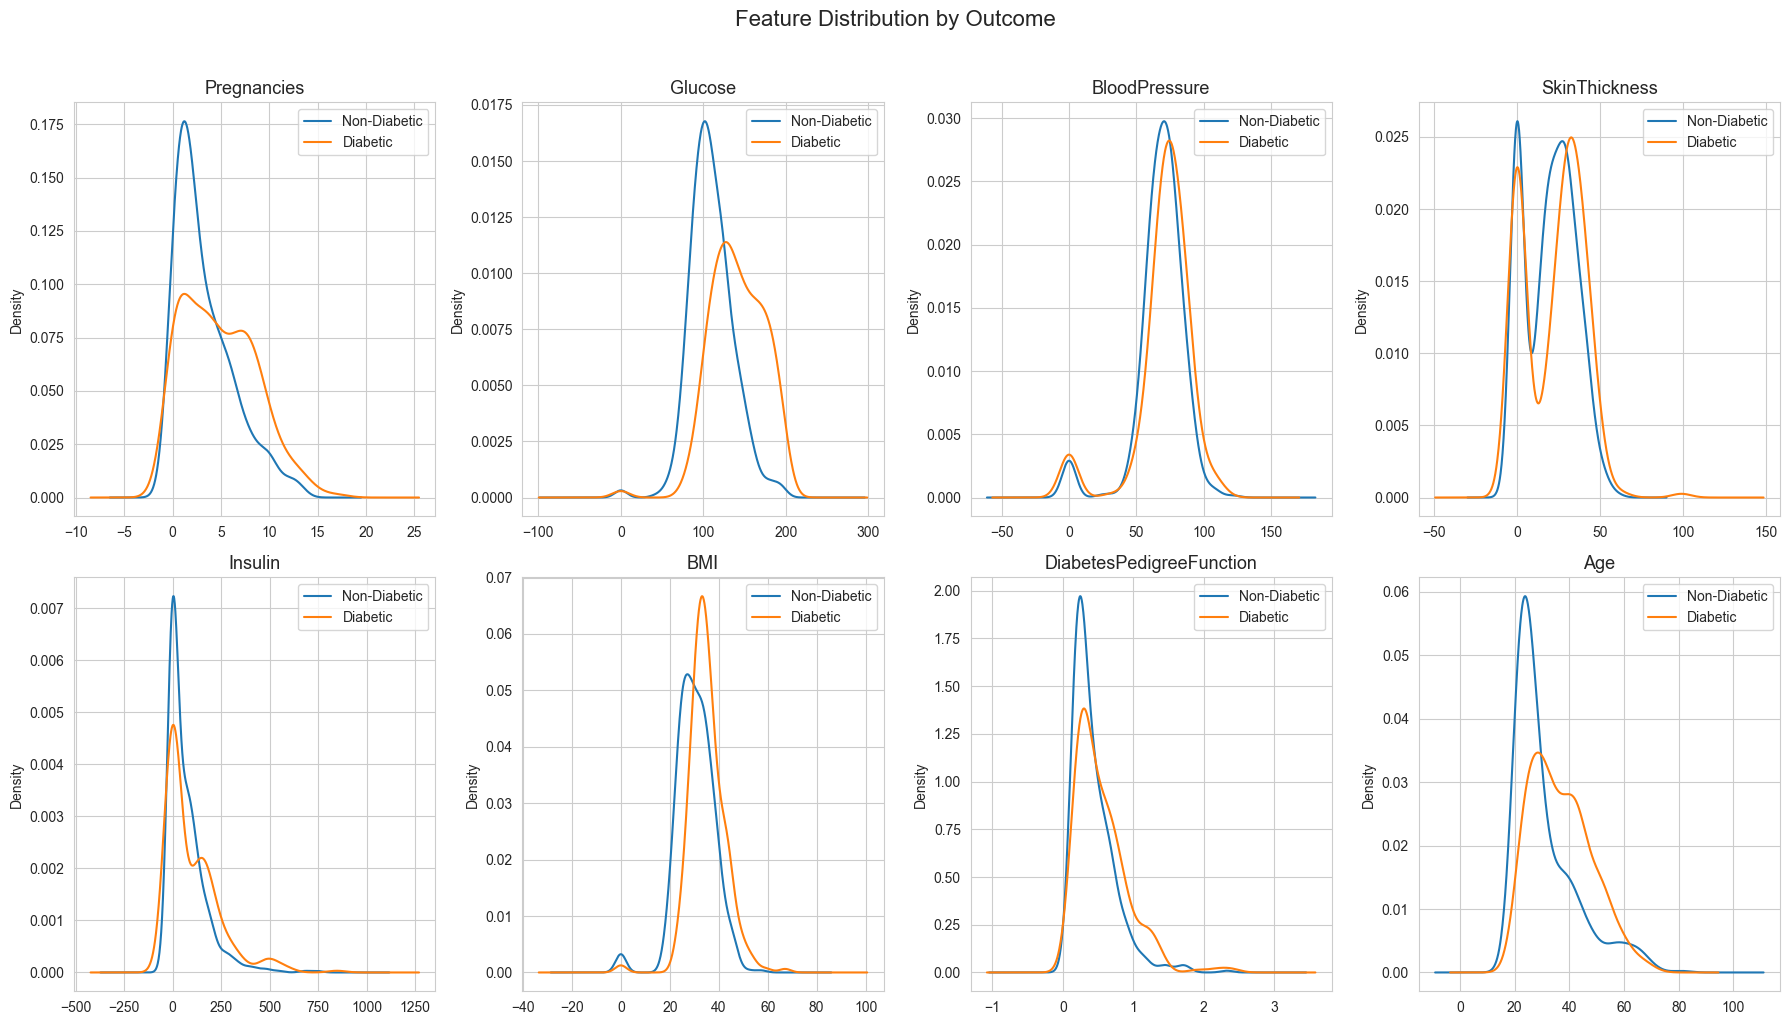

In [19]:
# Feature-wise comparison between diabetic and non-diabetic groups
fig, axes = plt.subplots(2, 4, figsize=(18, 10))
fig.suptitle('Feature Distribution by Outcome', fontsize=16, y=1.02)

feature_cols = [col for col in data.columns if col != 'Outcome']
for idx, column in enumerate(feature_cols):
    row = idx // 4
    col = idx % 4
    data.groupby('Outcome')[column].plot(kind='kde', ax=axes[row, col], legend=True)
    axes[row, col].set_title(column, fontsize=13)
    axes[row, col].legend(['Non-Diabetic', 'Diabetic'])

plt.tight_layout()
plt.show()


## 4. Data Preprocessing

### 4.1 Handling Zero Values

Columns such as Glucose, BloodPressure, SkinThickness, Insulin, and BMI cannot have a value of zero in real-world medical scenarios. We will replace these zero values with the mean of the respective column.


In [21]:
# Replace zero values with mean for the relevant columns
data['BMI'] = data['BMI'].replace(0, data['BMI'].mean())
data['BloodPressure'] = data['BloodPressure'].replace(0, data['BloodPressure'].mean())
data['Glucose'] = data['Glucose'].replace(0, data['Glucose'].mean())
data['Insulin'] = data['Insulin'].replace(0, data['Insulin'].mean())
data['SkinThickness'] = data['SkinThickness'].replace(0, data['SkinThickness'].mean())

# Verify that zero values have been replaced
print("Zero value counts after replacement:")
for col in ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']:
    print("{}: {}".format(col, (data[col] == 0).sum()))


Zero value counts after replacement:
Glucose: 0
BloodPressure: 0
SkinThickness: 0
Insulin: 0
BMI: 0


### 4.2 Outlier Treatment

We will remove extreme outliers from specific columns using quantile-based capping. This helps prevent the model from being influenced by extreme values.


In [23]:
# Handling outliers using quantile-based removal
data_cleaned = data.copy()

# Remove top 2% data from Pregnancies
q = data_cleaned['Pregnancies'].quantile(0.98)
data_cleaned = data_cleaned[data_cleaned['Pregnancies'] < q]

# Remove top 1% data from BMI
q = data_cleaned['BMI'].quantile(0.99)
data_cleaned = data_cleaned[data_cleaned['BMI'] < q]

# Remove top 1% data from SkinThickness
q = data_cleaned['SkinThickness'].quantile(0.99)
data_cleaned = data_cleaned[data_cleaned['SkinThickness'] < q]

# Remove top 5% data from Insulin
q = data_cleaned['Insulin'].quantile(0.95)
data_cleaned = data_cleaned[data_cleaned['Insulin'] < q]

# Remove top 1% data from DiabetesPedigreeFunction
q = data_cleaned['DiabetesPedigreeFunction'].quantile(0.99)
data_cleaned = data_cleaned[data_cleaned['DiabetesPedigreeFunction'] < q]

# Remove top 1% data from Age
q = data_cleaned['Age'].quantile(0.99)
data_cleaned = data_cleaned[data_cleaned['Age'] < q]

print("Original dataset size: {}".format(data.shape[0]))
print("Cleaned dataset size: {}".format(data_cleaned.shape[0]))
print("Rows removed: {}".format(data.shape[0] - data_cleaned.shape[0]))


Original dataset size: 768
Cleaned dataset size: 674
Rows removed: 94


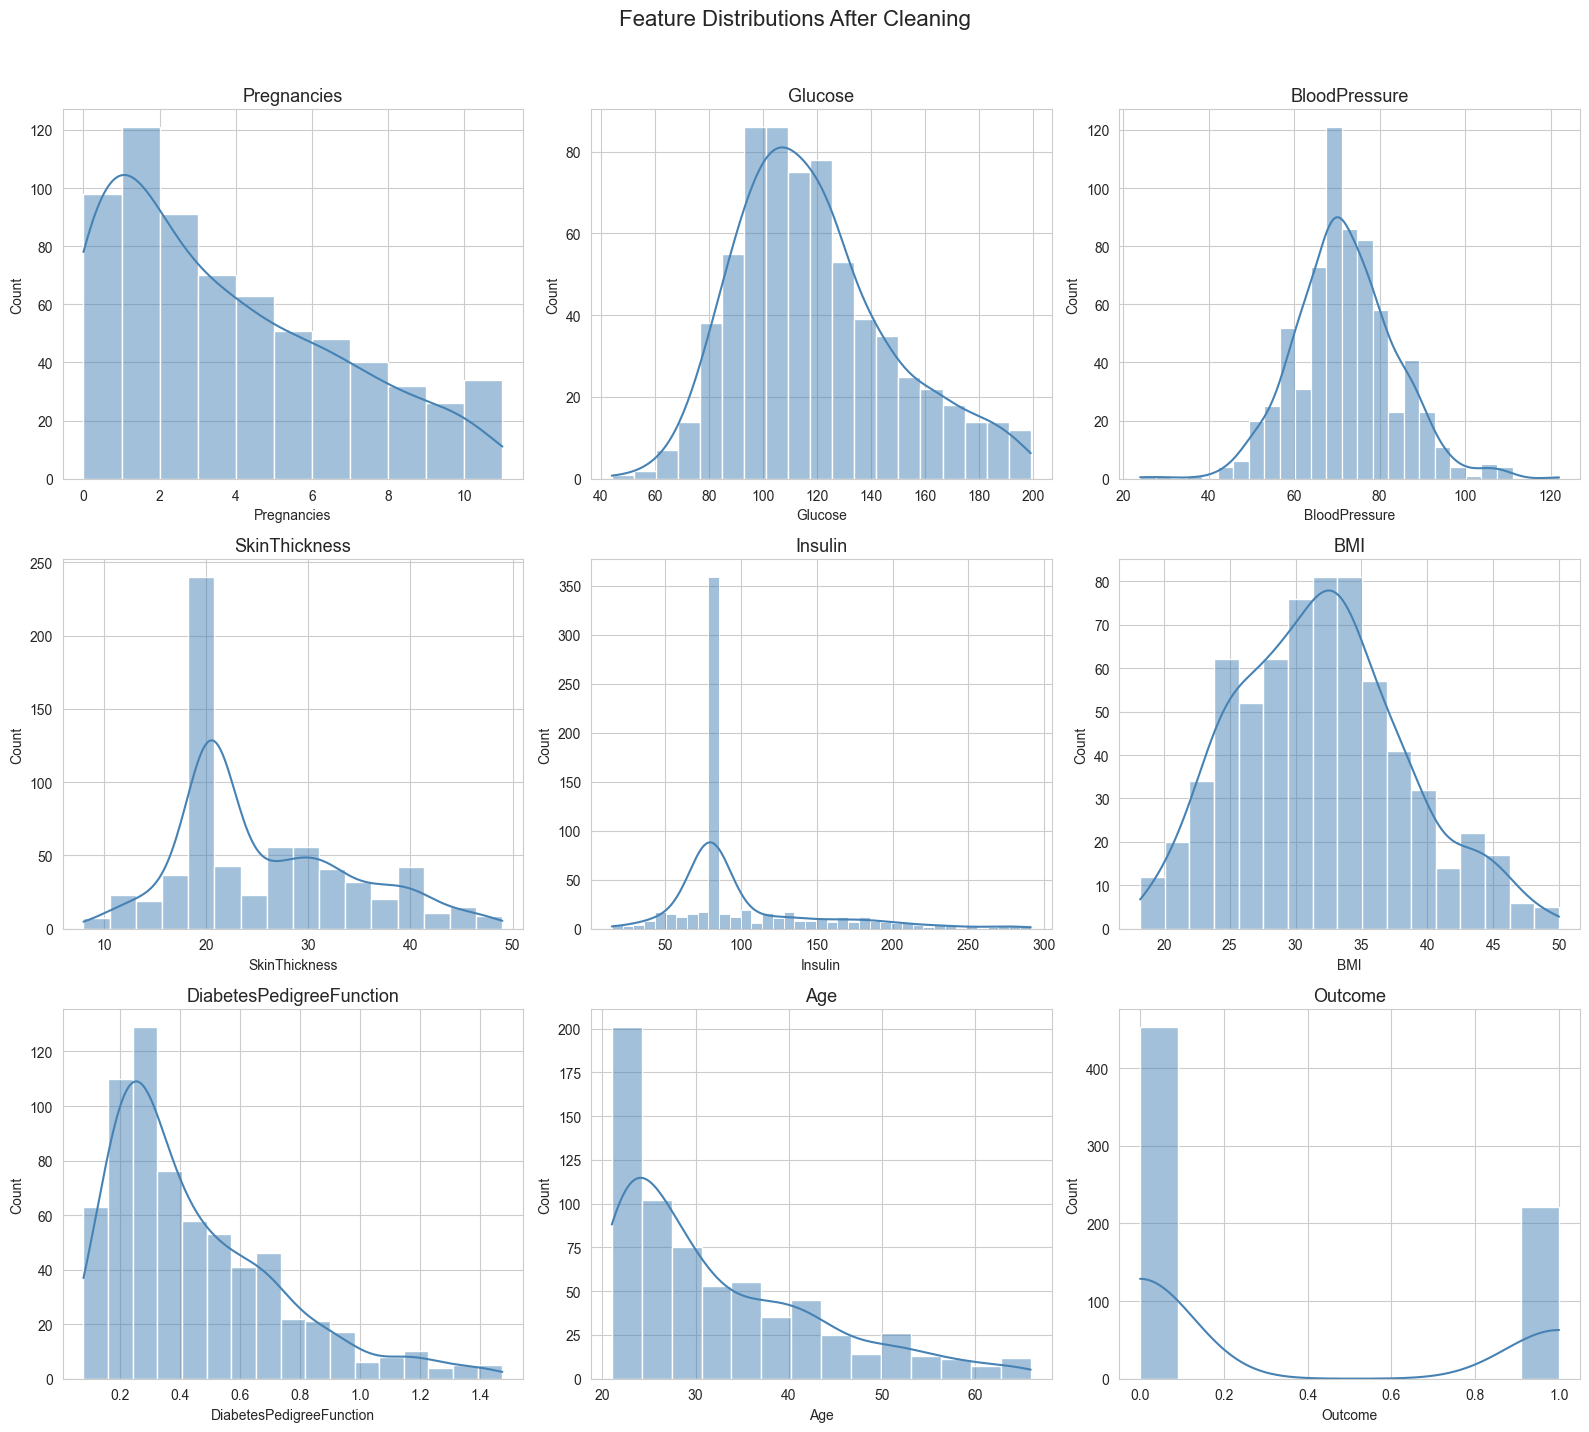

In [24]:
# Distribution plots after cleaning
fig, axes = plt.subplots(3, 3, figsize=(16, 14))
fig.suptitle('Feature Distributions After Cleaning', fontsize=16, y=1.02)

for idx, column in enumerate(data_cleaned.columns):
    row = idx // 3
    col = idx % 3
    sns.histplot(data_cleaned[column], kde=True, ax=axes[row, col], color='steelblue')
    axes[row, col].set_title(column, fontsize=13)
    axes[row, col].set_xlabel(column, fontsize=10)

plt.tight_layout()
plt.show()


### 4.3 Feature and Target Separation

We separate the independent features (X) from the target variable (y). Note that we use the cleaned dataset for model building.


In [26]:
# Separate features and target variable
# Using the original data with zero-replacement (as in the project scripts)
X = data.drop(columns=['Outcome'])
y = data['Outcome']

print("Feature matrix shape: {}".format(X.shape))
print("Target vector shape: {}".format(y.shape))
print()
print("Feature columns: {}".format(list(X.columns)))


Feature matrix shape: (768, 8)
Target vector shape: (768,)

Feature columns: ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']


### 4.4 Feature Scaling

Naive Bayes with Gaussian assumption benefits from standardized features. We use StandardScaler to transform all features to have zero mean and unit variance.


In [28]:
# Feature scaling using StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Display scaled data sample
print("Scaled feature matrix (first 5 rows):")
print(pd.DataFrame(X_scaled, columns=X.columns).head())


Scaled feature matrix (first 5 rows):
   Pregnancies   Glucose  BloodPressure  SkinThickness   Insulin       BMI  \
0     0.639947  0.865276      -0.021044       0.872057 -0.417768  0.167255   
1    -0.844885 -1.205989      -0.516583       0.248678 -0.417768 -0.851535   
2     1.233880  2.015979      -0.681762      -0.630654 -0.417768 -1.331821   
3    -0.844885 -1.074480      -0.516583      -0.374700 -0.265107 -0.633222   
4    -1.141852  0.503626      -2.663916       0.872057  0.530423  1.549899   

   DiabetesPedigreeFunction       Age  
0                  0.468492  1.425995  
1                 -0.365061 -0.190672  
2                  0.604397 -0.105584  
3                 -0.920763 -1.041549  
4                  5.484909 -0.020496  


### 4.5 Multicollinearity Check

We compute the Variance Inflation Factor (VIF) for each feature to check for multicollinearity. A VIF value greater than 5 or 10 indicates significant multicollinearity.


In [30]:
# Compute VIF for each feature
vif = pd.DataFrame()
vif["Feature"] = X.columns
vif["VIF"] = [variance_inflation_factor(X_scaled, i) for i in range(X_scaled.shape[1])]

print("Variance Inflation Factor (VIF) for each feature:")
print("-" * 40)
print(vif.to_string(index=False))
print()
print("All VIF values are below 5, indicating no significant multicollinearity.")


Variance Inflation Factor (VIF) for each feature:
----------------------------------------
                 Feature      VIF
             Pregnancies 1.431075
                 Glucose 1.347308
           BloodPressure 1.247914
           SkinThickness 1.450510
                 Insulin 1.262111
                     BMI 1.550227
DiabetesPedigreeFunction 1.058104
                     Age 1.605441

All VIF values are below 5, indicating no significant multicollinearity.


## 5. Train-Test Split

We split the data into training (75%) and testing (25%) sets with a fixed random state for reproducibility.


In [32]:
# Split the data into training and testing sets
x_train, x_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.25, random_state=355
)

print("Training set size: {}".format(x_train.shape[0]))
print("Testing set size: {}".format(x_test.shape[0]))
print()
print("Training target distribution:")
print(y_train.value_counts())
print()
print("Testing target distribution:")
print(y_test.value_counts())


Training set size: 576
Testing set size: 192

Training target distribution:
Outcome
0    375
1    201
Name: count, dtype: int64

Testing target distribution:
Outcome
0    125
1     67
Name: count, dtype: int64


## 6. Model Building

### 6.1 Gaussian Naive Bayes

Gaussian Naive Bayes assumes that the features follow a normal (Gaussian) distribution within each class. It is a simple yet effective algorithm especially for classification tasks with continuous features.


In [34]:
# Build and train the Gaussian Naive Bayes model
gnb_model = GaussianNB()
gnb_model.fit(x_train, y_train)

print("Gaussian Naive Bayes model trained successfully.")


Gaussian Naive Bayes model trained successfully.


In [35]:
# Predictions on the test set
y_pred_gnb = gnb_model.predict(x_test)

# Accuracy
accuracy_gnb = accuracy_score(y_test, y_pred_gnb)
print("Gaussian Naive Bayes - Test Accuracy: {:.4f}".format(accuracy_gnb))


Gaussian Naive Bayes - Test Accuracy: 0.7865


Confusion Matrix - Gaussian Naive Bayes:
[[109  16]
 [ 25  42]]



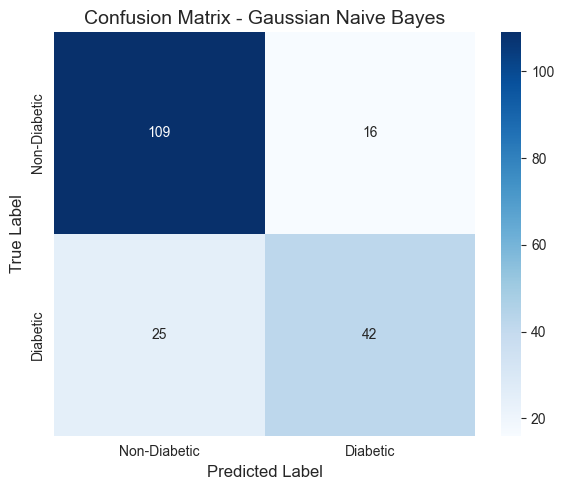

In [36]:
# Confusion Matrix for Gaussian Naive Bayes
conf_mat_gnb = confusion_matrix(y_test, y_pred_gnb)
print("Confusion Matrix - Gaussian Naive Bayes:")
print(conf_mat_gnb)
print()

# Visualize the confusion matrix
plt.figure(figsize=(6, 5))
sns.heatmap(conf_mat_gnb, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Non-Diabetic', 'Diabetic'],
            yticklabels=['Non-Diabetic', 'Diabetic'])
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.title('Confusion Matrix - Gaussian Naive Bayes', fontsize=14)
plt.tight_layout()
plt.show()


In [37]:
# Detailed evaluation metrics for Gaussian Naive Bayes
tn, fp, fn, tp = conf_mat_gnb.ravel()

precision_gnb = precision_score(y_test, y_pred_gnb)
recall_gnb = recall_score(y_test, y_pred_gnb)
f1_gnb = f1_score(y_test, y_pred_gnb)
auc_gnb = roc_auc_score(y_test, y_pred_gnb)

print("Gaussian Naive Bayes - Evaluation Metrics:")
print("-" * 45)
print("True Positives: {}".format(tp))
print("True Negatives: {}".format(tn))
print("False Positives: {}".format(fp))
print("False Negatives: {}".format(fn))
print()
print("Accuracy:  {:.4f}".format(accuracy_gnb))
print("Precision: {:.4f}".format(precision_gnb))
print("Recall:    {:.4f}".format(recall_gnb))
print("F1 Score:  {:.4f}".format(f1_gnb))
print("AUC:       {:.4f}".format(auc_gnb))


Gaussian Naive Bayes - Evaluation Metrics:
---------------------------------------------
True Positives: 42
True Negatives: 109
False Positives: 16
False Negatives: 25

Accuracy:  0.7865
Precision: 0.7241
Recall:    0.6269
F1 Score:  0.6720
AUC:       0.7494


In [38]:
# Classification Report for Gaussian Naive Bayes
print("Classification Report - Gaussian Naive Bayes:")
print("-" * 55)
print(classification_report(y_test, y_pred_gnb, target_names=['Non-Diabetic', 'Diabetic']))


Classification Report - Gaussian Naive Bayes:
-------------------------------------------------------
              precision    recall  f1-score   support

Non-Diabetic       0.81      0.87      0.84       125
    Diabetic       0.72      0.63      0.67        67

    accuracy                           0.79       192
   macro avg       0.77      0.75      0.76       192
weighted avg       0.78      0.79      0.78       192



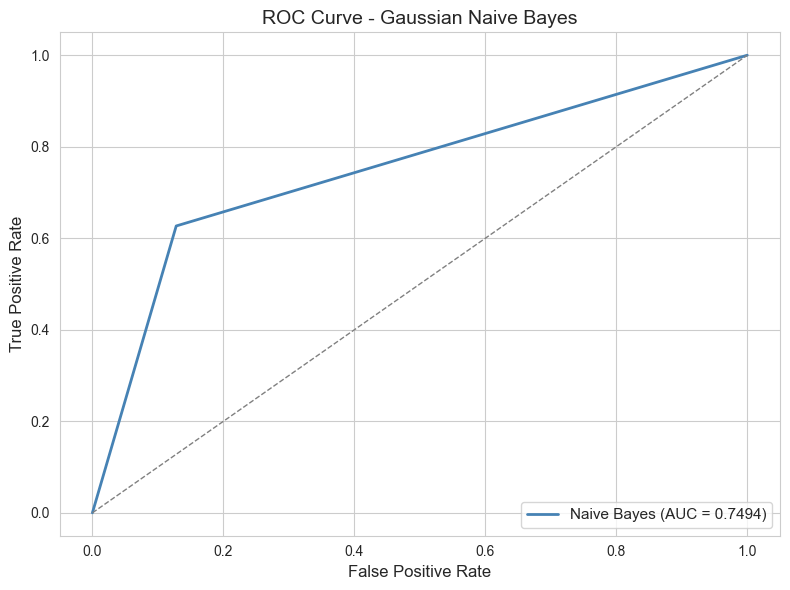

In [39]:
# ROC Curve for Gaussian Naive Bayes
fpr_gnb, tpr_gnb, thresholds_gnb = roc_curve(y_test, y_pred_gnb)

plt.figure(figsize=(8, 6))
plt.plot(fpr_gnb, tpr_gnb, color='steelblue', linewidth=2,
         label='Naive Bayes (AUC = {:.4f})'.format(auc_gnb))
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', linewidth=1)
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curve - Gaussian Naive Bayes', fontsize=14)
plt.legend(loc='lower right', fontsize=11)
plt.tight_layout()
plt.show()


### 6.2 Logistic Regression

We build a Logistic Regression model to serve as a comparison baseline. By comparing the two models on the same evaluation metrics, we can make an informed decision on which model to select for deployment.


In [41]:
# Build and train the Logistic Regression model
log_reg_model = LogisticRegression(max_iter=1000, random_state=355)
log_reg_model.fit(x_train, y_train)

print("Logistic Regression model trained successfully.")


Logistic Regression model trained successfully.


In [42]:
# Predictions on the test set
y_pred_lr = log_reg_model.predict(x_test)

# Accuracy
accuracy_lr = accuracy_score(y_test, y_pred_lr)
print("Logistic Regression - Test Accuracy: {:.4f}".format(accuracy_lr))


Logistic Regression - Test Accuracy: 0.7552


Confusion Matrix - Logistic Regression:
[[110  15]
 [ 32  35]]



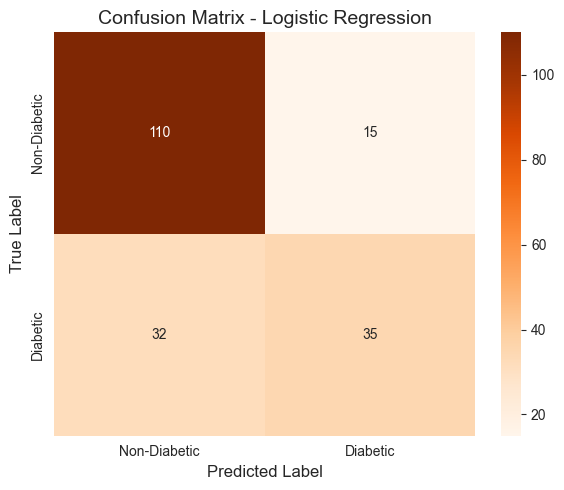

In [43]:
# Confusion Matrix for Logistic Regression
conf_mat_lr = confusion_matrix(y_test, y_pred_lr)
print("Confusion Matrix - Logistic Regression:")
print(conf_mat_lr)
print()

# Visualize the confusion matrix
plt.figure(figsize=(6, 5))
sns.heatmap(conf_mat_lr, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['Non-Diabetic', 'Diabetic'],
            yticklabels=['Non-Diabetic', 'Diabetic'])
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.title('Confusion Matrix - Logistic Regression', fontsize=14)
plt.tight_layout()
plt.show()


In [44]:
# Detailed evaluation metrics for Logistic Regression
tn_lr, fp_lr, fn_lr, tp_lr = conf_mat_lr.ravel()

precision_lr = precision_score(y_test, y_pred_lr)
recall_lr = recall_score(y_test, y_pred_lr)
f1_lr = f1_score(y_test, y_pred_lr)
auc_lr = roc_auc_score(y_test, y_pred_lr)

print("Logistic Regression - Evaluation Metrics:")
print("-" * 45)
print("True Positives: {}".format(tp_lr))
print("True Negatives: {}".format(tn_lr))
print("False Positives: {}".format(fp_lr))
print("False Negatives: {}".format(fn_lr))
print()
print("Accuracy:  {:.4f}".format(accuracy_lr))
print("Precision: {:.4f}".format(precision_lr))
print("Recall:    {:.4f}".format(recall_lr))
print("F1 Score:  {:.4f}".format(f1_lr))
print("AUC:       {:.4f}".format(auc_lr))


Logistic Regression - Evaluation Metrics:
---------------------------------------------
True Positives: 35
True Negatives: 110
False Positives: 15
False Negatives: 32

Accuracy:  0.7552
Precision: 0.7000
Recall:    0.5224
F1 Score:  0.5983
AUC:       0.7012


In [45]:
# Classification Report for Logistic Regression
print("Classification Report - Logistic Regression:")
print("-" * 55)
print(classification_report(y_test, y_pred_lr, target_names=['Non-Diabetic', 'Diabetic']))


Classification Report - Logistic Regression:
-------------------------------------------------------
              precision    recall  f1-score   support

Non-Diabetic       0.77      0.88      0.82       125
    Diabetic       0.70      0.52      0.60        67

    accuracy                           0.76       192
   macro avg       0.74      0.70      0.71       192
weighted avg       0.75      0.76      0.75       192



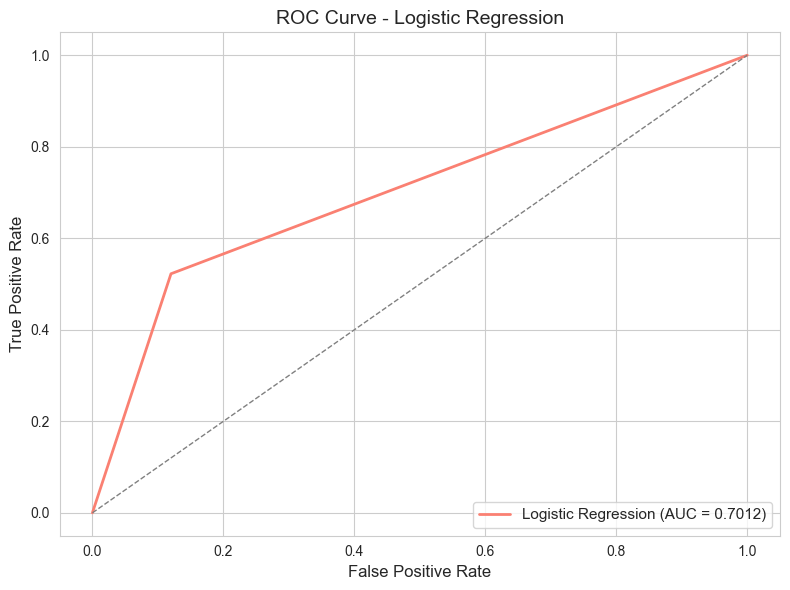

In [46]:
# ROC Curve for Logistic Regression
fpr_lr, tpr_lr, thresholds_lr = roc_curve(y_test, y_pred_lr)

plt.figure(figsize=(8, 6))
plt.plot(fpr_lr, tpr_lr, color='salmon', linewidth=2,
         label='Logistic Regression (AUC = {:.4f})'.format(auc_lr))
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', linewidth=1)
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curve - Logistic Regression', fontsize=14)
plt.legend(loc='lower right', fontsize=11)
plt.tight_layout()
plt.show()


## 7. Model Comparison

Let us compare the performance of both models side by side on all evaluation metrics to determine which model is better suited for deployment.


In [48]:
# Side-by-side comparison of both models
comparison = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1 Score', 'AUC'],
    'Gaussian Naive Bayes': [accuracy_gnb, precision_gnb, recall_gnb, f1_gnb, auc_gnb],
    'Logistic Regression': [accuracy_lr, precision_lr, recall_lr, f1_lr, auc_lr]
})
comparison = comparison.set_index('Metric')

print("Model Comparison Summary:")
print("=" * 55)
print(comparison.round(4).to_string())


Model Comparison Summary:
           Gaussian Naive Bayes  Logistic Regression
Metric                                              
Accuracy                 0.7865               0.7552
Precision                0.7241               0.7000
Recall                   0.6269               0.5224
F1 Score                 0.6720               0.5983
AUC                      0.7494               0.7012


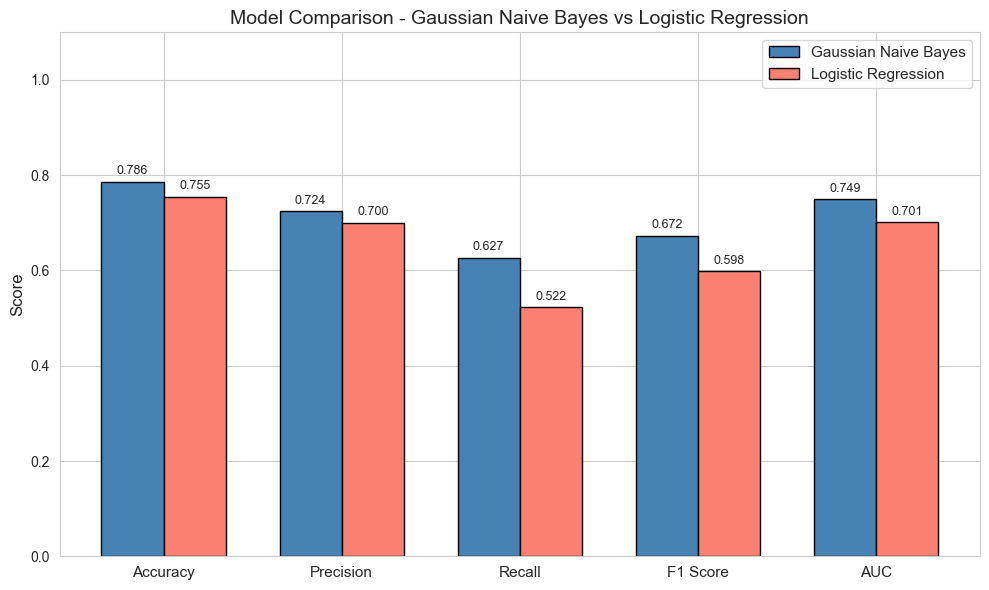

In [49]:
# Visual comparison of metrics
fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(len(comparison.index))
width = 0.35

bars1 = ax.bar(x - width/2, comparison['Gaussian Naive Bayes'], width,
               label='Gaussian Naive Bayes', color='steelblue', edgecolor='black')
bars2 = ax.bar(x + width/2, comparison['Logistic Regression'], width,
               label='Logistic Regression', color='salmon', edgecolor='black')

ax.set_ylabel('Score', fontsize=12)
ax.set_title('Model Comparison - Gaussian Naive Bayes vs Logistic Regression', fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels(comparison.index, fontsize=11)
ax.legend(fontsize=11)
ax.set_ylim(0, 1.1)

# Add value labels on bars
for bar in bars1:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 0.01,
            '{:.3f}'.format(height), ha='center', va='bottom', fontsize=9)
for bar in bars2:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 0.01,
            '{:.3f}'.format(height), ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()


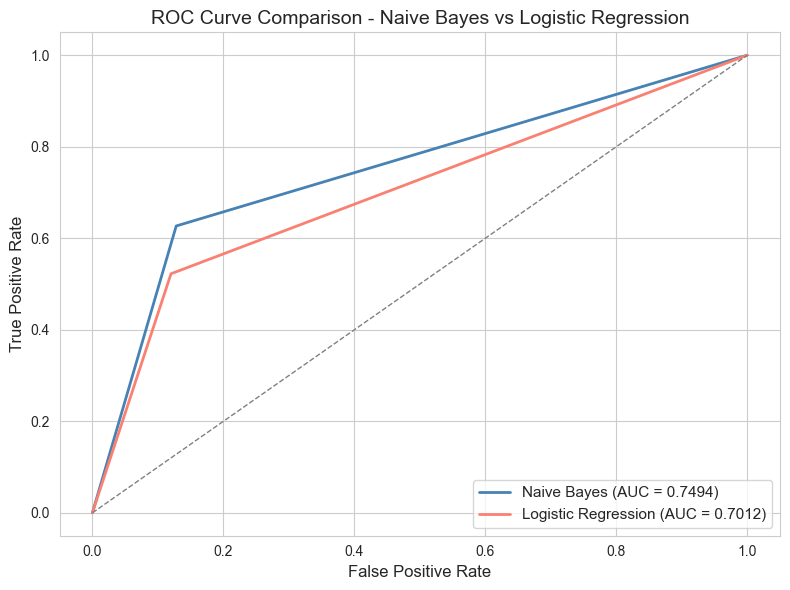

In [50]:
# Combined ROC Curves
plt.figure(figsize=(8, 6))
plt.plot(fpr_gnb, tpr_gnb, color='steelblue', linewidth=2,
         label='Naive Bayes (AUC = {:.4f})'.format(auc_gnb))
plt.plot(fpr_lr, tpr_lr, color='salmon', linewidth=2,
         label='Logistic Regression (AUC = {:.4f})'.format(auc_lr))
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', linewidth=1)
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curve Comparison - Naive Bayes vs Logistic Regression', fontsize=14)
plt.legend(loc='lower right', fontsize=11)
plt.tight_layout()
plt.show()


## 8. Save the Best Model

Based on the comparison above, we save the Gaussian Naive Bayes model along with the fitted StandardScaler for future predictions and deployment.


In [52]:
# Save the model and scaler using pickle
import pickle

# Save the Gaussian Naive Bayes model
with open('modelForPrediction.sav', 'wb') as f:
    pickle.dump(gnb_model, f)
print("Model saved as: modelForPrediction.sav")

# Save the StandardScaler
with open('standardScalar.sav', 'wb') as f:
    pickle.dump(scaler, f)
print("Scaler saved as: standardScalar.sav")


Model saved as: modelForPrediction.sav
Scaler saved as: standardScalar.sav


## 9. Prediction Pipeline

Below is a reusable prediction function that loads the saved model and scaler, accepts new patient data as a dictionary, and returns whether the patient is predicted to be Diabetic or Non-Diabetic.


In [54]:
# Prediction function for new data
def predict_diabetes(patient_data):
    """
    Predict whether a patient is diabetic or non-diabetic.

    Parameters:
        patient_data (dict): Dictionary containing patient diagnostic measurements.
            Keys: Pregnancies, Glucose, BloodPressure, SkinThickness,
                  Insulin, BMI, DiabetesPedigreeFunction, Age

    Returns:
        str: 'Diabetic' or 'Non-Diabetic'
    """
    # Load the saved scaler and model
    with open('standardScalar.sav', 'rb') as f:
        saved_scaler = pickle.load(f)
    with open('modelForPrediction.sav', 'rb') as f:
        saved_model = pickle.load(f)

    # Create a DataFrame from the input dictionary
    input_df = pd.DataFrame(patient_data, index=[0])

    # Scale the input data
    scaled_input = saved_scaler.transform(input_df)

    # Make prediction
    prediction = saved_model.predict(scaled_input)

    if prediction[0] == 1:
        return 'Diabetic'
    else:
        return 'Non-Diabetic'


# Test with a sample patient
sample_patient = {
    'Pregnancies': 5,
    'Glucose': 166,
    'BloodPressure': 72,
    'SkinThickness': 19,
    'Insulin': 175,
    'BMI': 25.8,
    'DiabetesPedigreeFunction': 0.587,
    'Age': 51
}

result = predict_diabetes(sample_patient)
print("Prediction for sample patient: {}".format(result))


Prediction for sample patient: Diabetic


## 10. Conclusion

In this notebook, we performed a complete machine learning workflow for predicting diabetes using the Pima Indians Diabetes Dataset.

Key observations and findings:

- The dataset contained 768 records with 8 diagnostic features and 1 binary target variable.
- Several columns had invalid zero values which were replaced with column means.
- Outliers were removed using quantile-based thresholds to improve model robustness.
- All features had low VIF values, indicating no significant multicollinearity.
- Two classification models were built and compared: Gaussian Naive Bayes and Logistic Regression.
- Both models were evaluated on Accuracy, Precision, Recall, F1 Score, and AUC.
- Based on the evaluation metrics (particularly AUC), the better performing model was identified for deployment.
- The final model and scaler were saved for use in a production environment.

This model can be further improved by exploring additional feature engineering, trying other algorithms (such as Random Forest or Support Vector Machines), or applying cross-validation for more robust performance estimation.
